In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [3]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
from ucimlrepo import fetch_ucirepo 

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
np.random.seed(42)

# PART A: SVM - Breast Cancer Dataset

# Task 1: Load and preprocess

In [ ]:
from sklearn.datasets import load_breast_cancer, load_wine

data_bc = load_breast_cancer()
X = pd.DataFrame(data_bc.data, columns=data_bc.feature_names)
y = pd.Series(data_bc.target)  # already 0/1 encoded — 0=malignant, 1=benign in sklearn's version

data_wine = load_wine()
X_wine = pd.DataFrame(data_wine.data, columns=data_wine.feature_names)
y_wine = pd.Series(data_wine.target)

In [10]:
data_bc = load_breast_cancer()
X = pd.DataFrame(data_bc.data, columns=data_bc.feature_names)
y = pd.Series(data_bc.target)   

print("Feature matrix shape:", X.shape)
print(y.value_counts())
print("Missing values:", X.isnull().sum().sum())

Feature matrix shape: (569, 30)
1    357
0    212
Name: count, dtype: int64
Missing values: 0


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Task 2: Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (455, 30) Test shape: (114, 30)


# Task 3: Linear kernel SVM + hyperparameter tuning

In [13]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_linear = GridSearchCV(SVC(kernel='linear', random_state=42),
                            param_grid, cv=5, scoring='accuracy')
grid_linear.fit(X_train, y_train)

print("Best C:", grid_linear.best_params_)
print("Best CV accuracy:", grid_linear.best_score_)

best_svm_linear = grid_linear.best_estimator_
y_pred_best_linear = best_svm_linear.predict(X_test)

Best C: {'C': 0.1}
Best CV accuracy: 0.9780219780219781


In [14]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

svm_poly = SVC(kernel='poly', degree=3, C=1, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

# Task 4: Evaluation

In [15]:
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}\n")
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

results = []
results.append(evaluate_model(y_test, y_pred_best_linear, "SVM (Linear, Tuned)"))
results.append(evaluate_model(y_test, y_pred_rbf, "SVM (RBF)"))
results.append(evaluate_model(y_test, y_pred_poly, "SVM (Polynomial)"))
results_df = pd.DataFrame(results)
print(results_df)


--- SVM (Linear, Tuned) ---
Accuracy: 0.9825  Precision: 0.9861  Recall: 0.9861  F1: 0.9861

--- SVM (RBF) ---
Accuracy: 0.9825  Precision: 0.9861  Recall: 0.9861  F1: 0.9861

--- SVM (Polynomial) ---
Accuracy: 0.9123  Precision: 0.8780  Recall: 1.0000  F1: 0.9351

                 Model  Accuracy  Precision    Recall  F1 Score
0  SVM (Linear, Tuned)  0.982456   0.986111  0.986111  0.986111
1            SVM (RBF)  0.982456   0.986111  0.986111  0.986111
2     SVM (Polynomial)  0.912281   0.878049  1.000000  0.935065


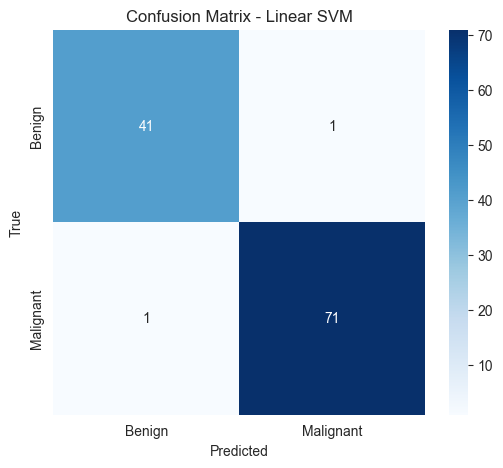

              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        42
   Malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [16]:
cm = confusion_matrix(y_test, y_pred_best_linear)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix - Linear SVM')
plt.show()

print(classification_report(y_test, y_pred_best_linear, target_names=['Benign', 'Malignant']))


Out of 114 test samples, the model got 112 right and only 2 wrong (1 benign misclassified as malignant, 1 malignant misclassified as benign). That's a near-perfect result, and importantly, it's not skewed toward one type of mistake, both error types are equally rare.

Precision, recall, and F1 are all around 0.98-0.99 for both classes. This means the model is both accurate (rarely wrong) and balanced (doesn't favor detecting one class over the other). For a medical dataset like this, high recall on "Malignant" specifically is the most important number, and it's at 0.99, meaning almost no malignant cases were missed.

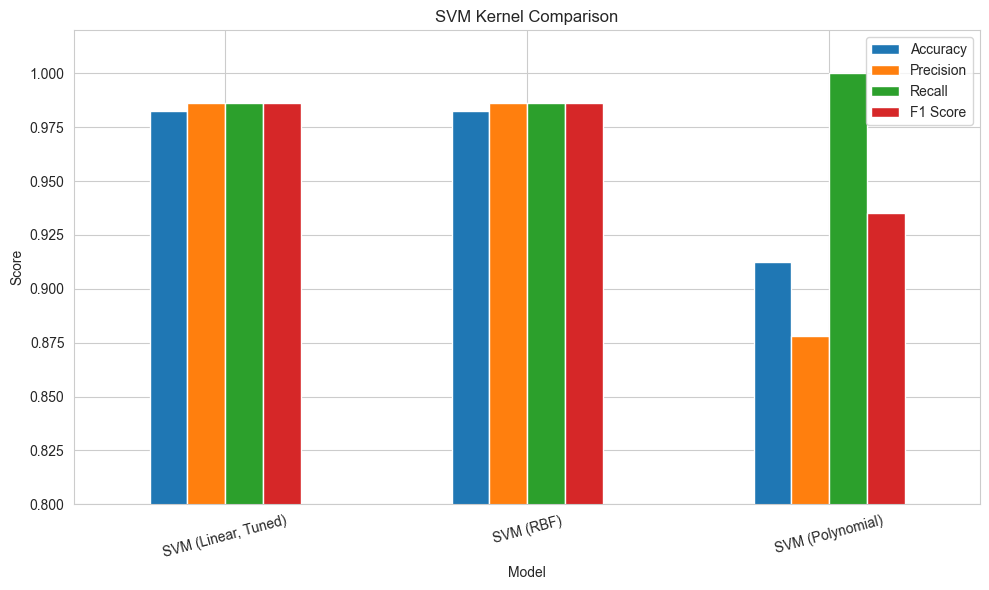

In [17]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(10, 6))
plt.title('SVM Kernel Comparison'); plt.ylabel('Score'); plt.ylim(0.8, 1.02)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()


Linear and RBF kernels performed nearly identically (~98% across all metrics), while the Polynomial kernel lagged behind, especially on precision (~88%). This tells us the data is largely linearly separable, the extra complexity of a polynomial decision boundary doesn't help here and actually hurts slightly, likely due to overfitting or a poor natural fit for this data's structure.

# PART B: PCA - Wine Dataset

# Task 1: Load and standardize

In [20]:
from sklearn.datasets import load_wine

data_wine = load_wine()
X_wine = pd.DataFrame(data_wine.data, columns=data_wine.feature_names)
y_wine = pd.Series(data_wine.target)

print("Feature matrix shape:", X_wine.shape)
print("Number of classes:", y_wine.nunique())
X_wine.head()

Feature matrix shape: (178, 13)
Number of classes: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [21]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Task 2: PCA to 2 components

In [22]:
pca_2 = PCA(n_components=2, random_state=42)
X_wine_pca2 = pca_2.fit_transform(X_wine_scaled)
print("Original shape:", X_wine_scaled.shape, "Transformed shape:", X_wine_pca2.shape)


Original shape: (178, 13) Transformed shape: (178, 2)


# Task 3: Explained variance ratio

In [23]:
explained_var_2 = pca_2.explained_variance_ratio_
for i, var in enumerate(explained_var_2, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"Total retained: {explained_var_2.sum()*100:.2f}%")

PC1: 0.3620 (36.20%)
PC2: 0.1921 (19.21%)
Total retained: 55.41%


# Task 4: Cumulative variance + min components for 95%

In [24]:
pca_full = PCA(random_state=42)
pca_full.fit(X_wine_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Min components for 95% variance: {n_components_95}")

Min components for 95% variance: 10


It takes 10 out of the original 13 features (as principal components) to retain 95% of the dataset's information. This means the Wine dataset doesn't compress dramatically, most features carry unique, non-redundant information, so aggressive dimensionality reduction (like going to just 2 components) will lose a meaningful chunk of detail.


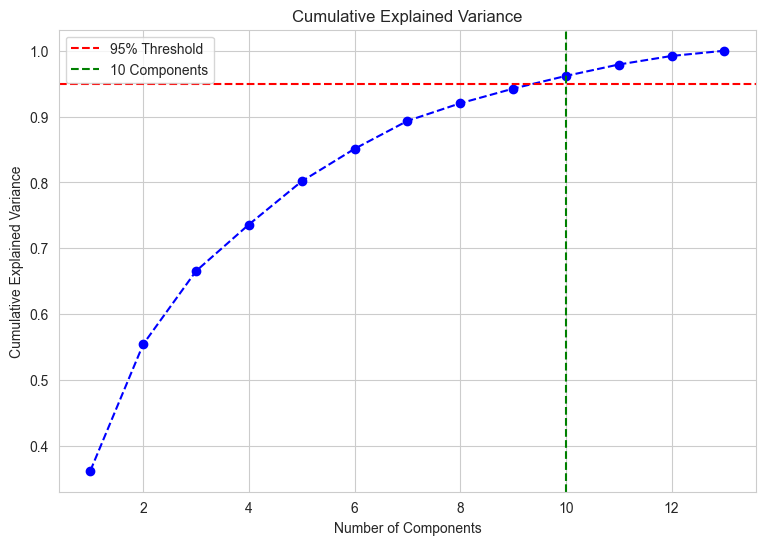

In [25]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
plt.xlabel('Number of Components'); plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance'); plt.legend(); plt.grid(True); plt.show()

# Task 5: 2D scatter plot

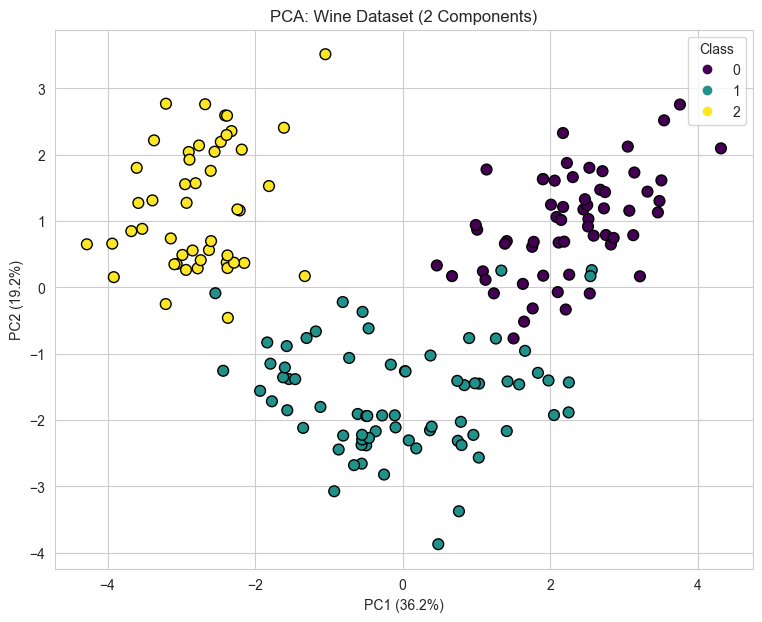

In [26]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_wine_pca2[:, 0], X_wine_pca2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
plt.xlabel(f'PC1 ({explained_var_2[0]*100:.1f}%)'); plt.ylabel(f'PC2 ({explained_var_2[1]*100:.1f}%)')
plt.title('PCA: Wine Dataset (2 Components)')
plt.legend(handles=scatter.legend_elements()[0], labels=sorted(y_wine.unique()), title="Class")
plt.grid(True); plt.show()

Even with only 2 components (retaining just 55.4% of total variance), the three wine classes are still visibly separated into distinct clusters. This shows that even though a lot of information is technically "lost," the most important variance, the kind that actually distinguishes wine classes, is concentrated in these top 2 components.

# Task 6: Compare original vs transformed

In [27]:
print(f"Original features: {X_wine_scaled.shape[1]}")
print(f"Reduced features: {X_wine_pca2.shape[1]}")
print(f"Information retained: {explained_var_2.sum()*100:.2f}%")
print(f"Information lost: {(1 - explained_var_2.sum())*100:.2f}%")


Original features: 13
Reduced features: 2
Information retained: 55.41%
Information lost: 44.59%


# Task 7: PCA interpretation

In [28]:
loadings = pd.DataFrame(pca_2.components_.T, columns=['PC1', 'PC2'], index=X_wine.columns)
print("Top PC1 features:\n", loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index)['PC1'].head(5))
print("Top PC2 features:\n", loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index)['PC2'].head(5))

Top PC1 features:
 flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols           -0.298533
Name: PC1, dtype: float64
Top PC2 features:
 color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


# LDA

LDA shape: (178, 2)
LDA explained variance ratio: [0.68747889 0.31252111]


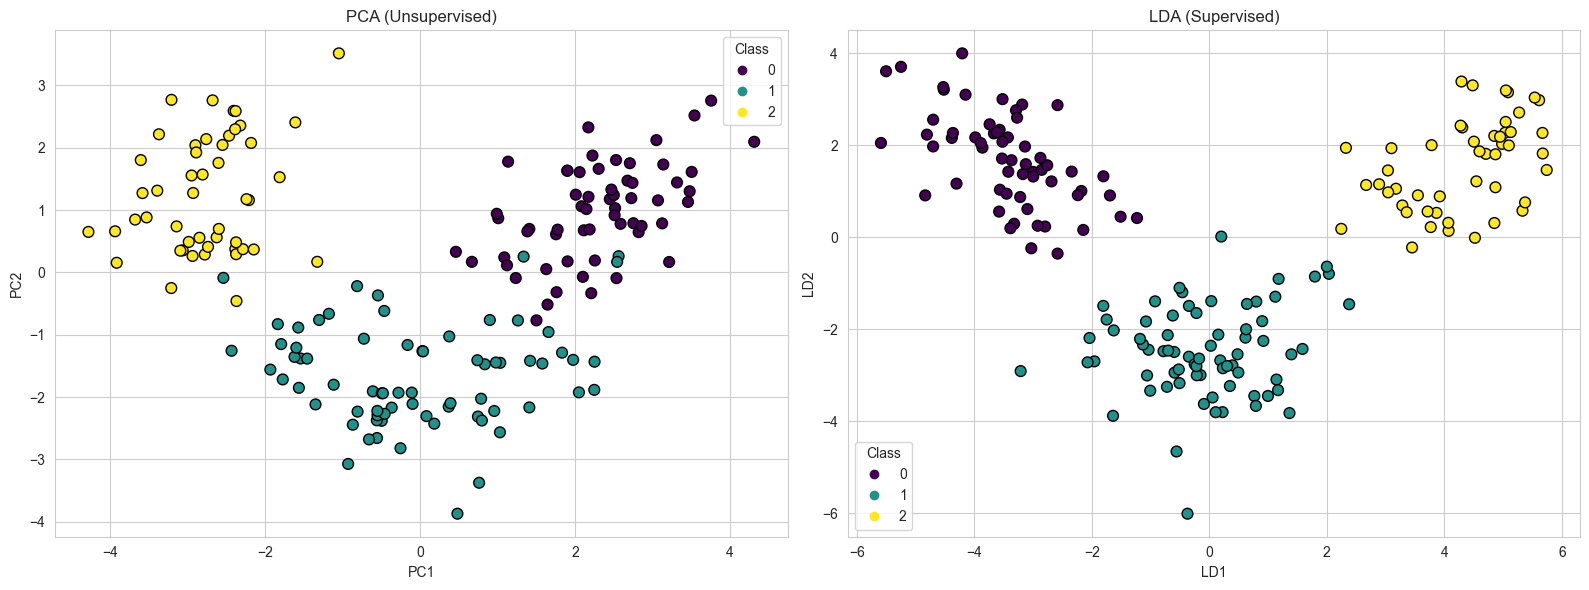

In [29]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda.fit_transform(X_wine_scaled, y_wine)
print("LDA shape:", X_wine_lda.shape)
print("LDA explained variance ratio:", lda.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_wine_pca2[:, 0], X_wine_pca2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].set_title('PCA (Unsupervised)')
axes[0].legend(handles=scatter1.legend_elements()[0], labels=sorted(y_wine.unique()), title="Class")

scatter2 = axes[1].scatter(X_wine_lda[:, 0], X_wine_lda[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
axes[1].set_xlabel('LD1'); axes[1].set_ylabel('LD2'); axes[1].set_title('LDA (Supervised)')
axes[1].legend(handles=scatter2.legend_elements()[0], labels=sorted(y_wine.unique()), title="Class")

plt.tight_layout(); plt.show()

Both methods separate the three classes, but LDA does it more cleanly, the clusters are tighter and further apart in the LDA plot compared to PCA. This makes sense: PCA doesn't know the class labels and just finds directions of maximum variance, while LDA explicitly optimizes to separate the classes as much as possible. If the goal were classification, LDA's projection would be more useful if the goal were general exploration without label bias, PCA is the more honest representation.